In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

In [2]:
# Load the CSV file
df = pd.read_csv('Phenology.csv')

# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Calculate historical average ice break up date per COMID (1995-2005)

In [3]:
# Filter for breakup events between 1995 and 2005
hist = df[
    (df['Event'] == 'breakup') &
    (df['Year'].between(1995, 2005))
]

# Group by COMID and calculate average breakup date
hist_avg = (
    hist
    .groupby('COMID')['Date']
    .mean()
    .reset_index()
    .rename(columns={'Date': 'Average_Breakup_Date'})
)

# Optional: Display the result
print(hist_avg)

          COMID          Average_Breakup_Date
0      81000004 2000-05-27 08:43:38.181818240
1      81000005 2000-05-29 06:32:43.636363648
2      81000006 2000-05-29 17:27:16.363636352
3      81000007 2000-05-26 00:00:00.000000000
4      81000011 2000-05-30 04:21:49.090909056
...         ...                           ...
34203  82001686 2000-05-28 15:16:21.818181760
34204  82001698 2000-05-28 10:54:32.727272704
34205  82001703 2000-05-26 04:21:49.090909056
34206  82001706 2000-05-26 19:38:10.909090944
34207  82001714 2000-05-29 04:21:49.090909056

[34208 rows x 2 columns]


# Find COMID nearest to villages

In [4]:
# Load COMID coordinates
loc_df = pd.read_csv('River_Segment_Locations.csv')

# Create GeoDataFrame from location data
gdf = gpd.GeoDataFrame(
    loc_df,
    geometry=gpd.points_from_xy(loc_df['Longitude'], loc_df['Latitude']),
    crs='EPSG:4326'
)

# Get all COMIDs present in Thickness data
comids_with_data = df['COMID'].unique()

# Subset gdf to only COMIDs that have data
gdf_with_data = gdf[gdf['COMID'].isin(comids_with_data)].copy()

# Reproject to a projected CRS for accurate distance (e.g., Alaska Albers)
gdf_with_data = gdf_with_data.to_crs(epsg=3338)

In [5]:
# Find COMID nearest to Fort Yukon

# Create and reproject the target point
fy_lat, fy_lon = 66.564722, -145.256667
fy_point = gpd.GeoSeries([Point(fy_lon, fy_lat)], crs='EPSG:4326').to_crs(epsg=3338).iloc[0]

# Compute distances
gdf_with_data['distance'] = gdf_with_data.geometry.distance(fy_point)

# Find the closest COMID
nearest_row = gdf_with_data.loc[gdf_with_data['distance'].idxmin()]

# Print result
print("Nearest COMID:")
print(nearest_row[['COMID', 'Latitude', 'Longitude', 'distance']])


Nearest COMID:
COMID           81010088
Latitude       66.555833
Longitude    -145.275833
distance     1305.820111
Name: 9653, dtype: object


In [6]:
# Find COMID nearest to Tanana

# Create and reproject the target point
tan_lat, tan_lon = 65.170833, -152.077778
tan_point = gpd.GeoSeries([Point(tan_lon, tan_lat)], crs='EPSG:4326').to_crs(epsg=3338).iloc[0]

# Compute distances
gdf_with_data['distance'] = gdf_with_data.geometry.distance(tan_point)

# Find the closest COMID
nearest_row = gdf_with_data.loc[gdf_with_data['distance'].idxmin()]

# Print result
print("Nearest COMID:")
print(nearest_row[['COMID', 'Latitude', 'Longitude', 'distance']])


Nearest COMID:
COMID           81012983
Latitude       65.166667
Longitude    -152.150833
distance     3457.060497
Name: 12437, dtype: object


In [7]:
# Find COMID nearest to Eagle

# Create and reproject the target point
eagle_lat, eagle_lon = 64.786022, -141.199917
eagle_point = gpd.GeoSeries([Point(eagle_lon, eagle_lat)], crs='EPSG:4326').to_crs(epsg=3338).iloc[0]

# Compute distances
gdf_with_data['distance'] = gdf_with_data.geometry.distance(eagle_point)

# Find the closest COMID
nearest_row = gdf_with_data.loc[gdf_with_data['distance'].idxmin()]

# Print result
print("Nearest COMID:")
print(nearest_row[['COMID', 'Latitude', 'Longitude', 'distance']])


Nearest COMID:
COMID           81014736
Latitude         64.7975
Longitude    -141.213333
distance     1430.143685
Name: 14179, dtype: object


In [8]:
# Find COMID nearest to Galena

# Create and reproject the target point
gal_lat, gal_lon = 64.740643, -156.885462
gal_point = gpd.GeoSeries([Point(gal_lon, gal_lat)], crs='EPSG:4326').to_crs(epsg=3338).iloc[0]

# Compute distances
gdf_with_data['distance'] = gdf_with_data.geometry.distance(gal_point)

# Find the closest COMID
nearest_row = gdf_with_data.loc[gdf_with_data['distance'].idxmin()]

# Print result
print("Nearest COMID:")
print(nearest_row[['COMID', 'Latitude', 'Longitude', 'distance']])


Nearest COMID:
COMID          81014218
Latitude      64.735833
Longitude      -156.875
distance     732.085123
Name: 13662, dtype: object


# Plot phenology over time

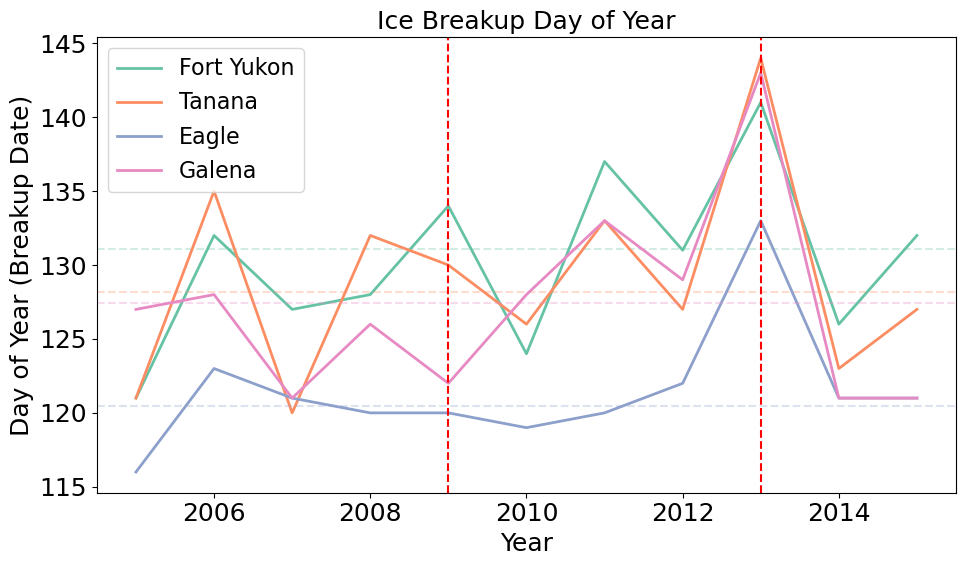

In [12]:
# Filter for breakup events and the specified COMID
comids = [81010088, 81012983, 81014736, 81014218]
comid_to_name = {
    81010088: 'Fort Yukon',
    81012983: 'Tanana',
    81014736: 'Eagle',
    81014218: 'Galena'
}
# Filter for breakup events for the selected COMIDs
breakup_df = df[(df['Event'] == 'breakup') & (df['COMID'].isin(comids))].copy()

# Plot
plt.figure(figsize=(10, 6))

colors = plt.cm.Set2.colors  # Get distinct colors
for i, comid in enumerate(comids):
    subset = breakup_df[breakup_df['COMID'] == comid]
    label = comid_to_name.get(comid, str(comid))
    color = colors[i % len(colors)]

    # Plot 2005–2015 data
    subset_recent = subset[subset['Year'].between(2005, 2015)]
    plt.plot(subset_recent['Year'], subset_recent['Date'].dt.dayofyear, label=label, color=color, linewidth=2)

    # Historical average from 1995–2005
    subset_historical = subset[subset['Year'].between(1995, 2005)]
    mean_doy = subset_historical['Date'].dt.dayofyear.mean()
    plt.axhline(y=mean_doy, linestyle='--', linewidth=1.5, color=color, alpha=0.3)
    
# Add vertical line at 2009
plt.axvline(x=2009, color='red', linestyle='--', linewidth=1.5)
plt.axvline(x=2013, color='red', linestyle='--', linewidth=1.5)

plt.rcParams.update({
    'font.size': 18,          # Base font size
    'axes.titlesize': 18,     # Subplot titles
    'axes.labelsize': 18,     # X and Y labels
    'xtick.labelsize': 18,    # X tick labels
    'ytick.labelsize': 18,    # Y tick labels
    'legend.fontsize': 16,    # Legend text
    'figure.titlesize': 20    # Figure title (if used)
})

plt.title('Ice Breakup Day of Year')
plt.xlabel('Year')
plt.ylabel('Day of Year (Breakup Date)')
plt.legend()
plt.tight_layout()
plt.savefig("Village_river_ice_phenology.pdf", format='pdf', bbox_inches='tight')
plt.show()

# Calculate departure from average

In [10]:
# Filter for breakup events and selected COMIDs
breakup_df = df[(df['Event'] == 'breakup') & (df['COMID'].isin(comids))].copy()

# Calculate departures
departure_results = []

for comid in comids:
    subset = breakup_df[breakup_df['COMID'] == comid]

    # Historical average (1995–2005)
    historical_subset = subset[subset['Year'].between(1995, 2005)]
    historical_mean_doy = historical_subset['Date'].dt.dayofyear.mean()

    # Compare to years 2009 and 2013
    for year in [2009, 2013]:
        year_subset = subset[subset['Year'] == year]
        if not year_subset.empty:
            actual_doy = year_subset['Date'].dt.dayofyear.values[0]
            departure = actual_doy - historical_mean_doy
            departure_results.append({
                'COMID': comid,
                'Village': comid_to_name[comid],
                'Year': year,
                'Breakup_DOY': actual_doy,
                'Historical_Avg_DOY': historical_mean_doy,
                'Departure': departure
            })

# Convert results to DataFrame
departure_df = pd.DataFrame(departure_results)

# Optional: view results
print(departure_df)

      COMID     Village  Year  Breakup_DOY  Historical_Avg_DOY  Departure
0  81010088  Fort Yukon  2009          134          131.090909   2.909091
1  81010088  Fort Yukon  2013          141          131.090909   9.909091
2  81012983      Tanana  2009          130          128.181818   1.818182
3  81012983      Tanana  2013          144          128.181818  15.818182
4  81014736       Eagle  2009          120          120.454545  -0.454545
5  81014736       Eagle  2013          133          120.454545  12.545455
6  81014218      Galena  2009          122          127.454545  -5.454545
7  81014218      Galena  2013          143          127.454545  15.545455
